# **Các Bước Chuẩn Bị:**
* **Bước 1: Đổi Accelerator của phiên làm việc thành GPU T4 x2**
* **Bước 2: Bật Internet (dưới Accelerator) để tải thư viện/mô hình Llama/Qwen/DeepSeek từ Hugging Face**
* **Bước 3: Add Token Hugging Face thông qua Add-ons của Kaggle**
* **Bước 4: Cài đặt unsloth để huấn luyện nhanh hơn, phù hợp cho điều kiện có hạn trên Kaggle**

In [1]:
%%capture
# Cài Unsloth phiên bản tối ưu cho Kaggle — bao gồm đủ dependency đúng phiên bản
!pip install "unsloth[kaggle-new] @ git+https://github.com/unslothai/unsloth.git"
# Chỉ upgrade TRL để có SFTConfig, dùng --no-deps để không phá vỡ các patch của unsloth
!pip install --upgrade --no-deps trl

In [2]:
import os
# Tạo thư mục figures để lưu toàn bộ ảnh xuất ra
os.makedirs('figures', exist_ok=True)
print("Đã tạo sẵn sàng thư mục 'figures/'")

Đã tạo sẵn sàng thư mục 'figures/'


# **Download dữ liệu đã được tiền xử lý từ bài báo gốc của tác giả**

In [3]:
import os
import urllib.request

# Tạo một thư mục tên là 'dataset' ngay trong môi trường làm việc của Kaggle
os.makedirs('/kaggle/working/dataset', exist_ok=True)

# Các đường dẫn Raw (dữ liệu thô) trực tiếp từ GitHub của tác giả
urls = {
    "train_set.csv": "https://raw.githubusercontent.com/Applied-AI-Research-Lab/Financial-Sentiment-Analysis-and-Classification-Deep-Learning-Models/main/Datasets/train_set.csv",
    "validation_set.csv": "https://raw.githubusercontent.com/Applied-AI-Research-Lab/Financial-Sentiment-Analysis-and-Classification-Deep-Learning-Models/main/Datasets/validation_set.csv",
    "test_set.csv": "https://raw.githubusercontent.com/Applied-AI-Research-Lab/Financial-Sentiment-Analysis-and-Classification-Deep-Learning-Models/main/Datasets/test_set.csv"
}

# Tiến hành tải về
for filename, url in urls.items():
    save_path = f'/kaggle/working/dataset/{filename}'
    urllib.request.urlretrieve(url, save_path)
    print(f"Tải thành công: {filename}")

Tải thành công: train_set.csv
Tải thành công: validation_set.csv
Tải thành công: test_set.csv


/tmp/ipykernel_23/31338300.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


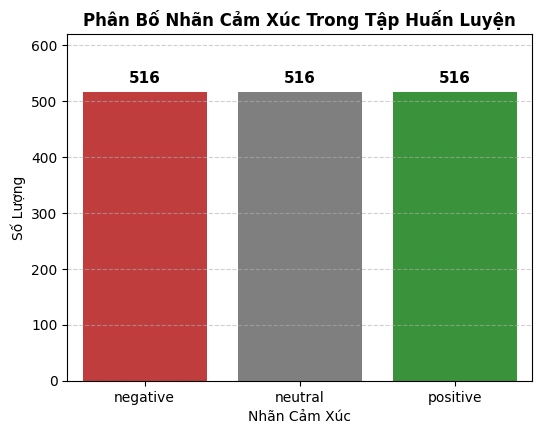

✅ Đã lưu thành công: figures/data_distribution.png


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    # Đọc dữ liệu Train
    train_df = pd.read_csv('/kaggle/working/dataset/train_set.csv')
    
    plt.figure(figsize=(6, 4.5))
    
    # Gán biểu đồ vào biến 'ax' để dễ dàng thêm text
    ax = sns.countplot(
        data=train_df, 
        x='Sentiment', 
        palette=['#d62728', '#7f7f7f', '#2ca02c'], 
        order=['negative', 'neutral', 'positive']
    )
    
    # Thêm con số chính xác lên đỉnh mỗi cột
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', padding=5, fontsize=11, fontweight='bold')
    
    # Nới rộng trục Y lên mức 600 để số 516 không bị đụng nóc biểu đồ
    plt.ylim(0, 620)
    
    plt.title('Phân Bố Nhãn Cảm Xúc Trong Tập Huấn Luyện', fontsize=12, fontweight='bold')
    plt.xlabel('Nhãn Cảm Xúc')
    plt.ylabel('Số Lượng')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    
    # Lưu ảnh DPI 150 theo đúng yêu cầu file MD
    plt.savefig('figures/data_distribution.png', bbox_inches='tight', dpi=150)
    plt.show()
    
    print("✅ Đã lưu thành công: figures/data_distribution.png")

except FileNotFoundError:
    print("❌ Lỗi: Không tìm thấy file train_set.csv. Vui lòng chạy cell tải dữ liệu trước!")

# **Tiền xử lý dữ liệu cho mô hình LLM**
**Mô hình ngôn ngữ (LLMS) như Llama/Qwen hay DeepSeek không học bằng cách đọc từng cột trong file CSV. Do đó, cần gom cột Sentence và Sentiment lại với nhau thành một đoạn hội thoại mẫu (Prompt) bao gồm 3 phần:**
1. **Instruction (Hướng dẫn):** Báo cho AI biết nó là một chuyên gia tài chính và cần làm gì.
2. **Input (Đầu vào):** Câu văn bản tài chính cần phân tích.
3. **Response (Câu trả lời):** Nhãn kết quả (negative, positive, hoặc neutral) dưới định dạng JSON.

In [5]:
import pandas as pd
from datasets import Dataset

# Đọc dữ liệu từ thư mục đã tải về
train_path = '/kaggle/working/dataset/train_set.csv'
val_path   = '/kaggle/working/dataset/validation_set.csv'

train_df = pd.read_csv(train_path)
val_df   = pd.read_csv(val_path)

# Định nghĩa khuôn mẫu Prompt (Chuẩn Alpaca)
alpaca_prompt = """Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:
You are an AI assistant specializing in financial sentiment classification. Your task is to analyze each financial sentence and classify it as negative, positive, or neutral. Provide your final classification in the following JSON format without explanations: {{"Sentiment": "sentiment_tag"}}.

### Input:
{sentence}

### Response:
{{"Sentiment": "{sentiment}"}}"""

# Hàm ánh xạ dữ liệu vào Prompt
# Escape { và } trong câu gốc trước khi format
#    → Tránh lỗi KeyError nếu câu tài chính chứa ký tự { hoặc } (vd: "grew by {5}%")
def format_prompts(row):
    safe_sentence = row["Sentence"].replace("{", "{{").replace("}", "}}")
    return alpaca_prompt.format(
        sentence=safe_sentence,
        sentiment=row["Sentiment"]
    )

# Áp dụng hàm để tạo cột 'text' chứa toàn bộ nội dung đã format
train_df['text'] = train_df.apply(format_prompts, axis=1)
val_df['text']   = val_df.apply(format_prompts, axis=1)

# Chuyển đổi DataFrame sang định dạng Dataset của Hugging Face (bắt buộc để huấn luyện)
train_dataset = Dataset.from_pandas(train_df[['text']])
val_dataset   = Dataset.from_pandas(val_df[['text']])

print(f"Đã chuẩn bị xong {len(train_dataset)} dòng Train và {len(val_dataset)} dòng Validation.")
print("\n" + "="*50)
print("XEM THỬ 1 MẪU DỮ LIỆU ĐÃ ĐƯỢC BIẾN ĐỔI:")
print("="*50 + "\n")
print(train_dataset['text'][0])
print("\n" + "="*50)

Đã chuẩn bị xong 1548 dòng Train và 516 dòng Validation.

XEM THỬ 1 MẪU DỮ LIỆU ĐÃ ĐƯỢC BIẾN ĐỔI:

Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:
You are an AI assistant specializing in financial sentiment classification. Your task is to analyze each financial sentence and classify it as negative, positive, or neutral. Provide your final classification in the following JSON format without explanations: {"Sentiment": "sentiment_tag"}.

### Input:
the use of validation rule base enables verifying that processing rule bases managed by different administrators fulfil some set requirements

### Response:
{"Sentiment": "neutral"}



# **Gọi mô hình**

In [6]:
from unsloth import FastLanguageModel
import torch

max_seq_length = 512
dtype          = None  # Tự động phát hiện kiểu dữ liệu phù hợp với GPU
load_in_4bit   = True  # Sử dụng nén 4-bit để không bị tràn RAM trên Kaggle

# Đọc HF Token an toàn từ Kaggle Secrets
# (Vào Add-ons → Secrets → Add secret với tên HF_TOKEN)
from kaggle_secrets import UserSecretsClient
try:
    hf_token = UserSecretsClient().get_secret("HF_TOKEN")
except:
    hf_token = None  # unsloth/DeepSeek-R1-Distill-Qwen-7B-bnb-4bit là bản public, không cần token vẫn chạy được

# 1. Tải mô hình DeepSeek-7B và Tokenizer
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name   = "unsloth/DeepSeek-R1-Distill-Qwen-7B-bnb-4bit",  # Phiên bản tối ưu cho GPU yếu
    max_seq_length = max_seq_length,
    dtype          = dtype,
    load_in_4bit   = load_in_4bit,
    token          = hf_token,  # None = tự động bỏ qua, không gây lỗi
)

# 2. Cấu hình kỹ thuật LoRA (PEFT)
model = FastLanguageModel.get_peft_model(
    model,
    r                        = 16,       # Rank của ma trận LoRA
    target_modules           = ["q_proj", "k_proj", "v_proj", "o_proj",
                                "gate_proj", "up_proj", "down_proj"],
    lora_alpha               = 16,
    lora_dropout             = 0,        # Để 0 với LoRA cho tốc độ học nhanh nhất
    bias                     = "none",
    use_gradient_checkpointing = "unsloth",  # Tối ưu RAM tối đa cho Kaggle
    random_state             = 3407,
    use_rslora               = False,
    loftq_config             = None,
)

print("Đã gọi thành công DeepSeek-7B và cấu hình LoRA")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.5.9: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.55G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/236 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

Unsloth: Will load unsloth/DeepSeek-R1-Distill-Qwen-7B-bnb-4bit as a legacy tokenizer.


unsloth/DeepSeek-R1-Distill-Qwen-7B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.5.9 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


Đã gọi thành công DeepSeek-7B và cấu hình LoRA


# **Huấn luyện mô hình (Fine-Tuning) với thuật toán LoRA**
Trong bước này, chúng ta sẽ sử dụng `SFTTrainer` (Supervised Fine-Tuning Trainer) để dạy DeepSeek-7B đọc hiểu các câu tài chính.  
Thay vì học lại toàn bộ 8 tỷ tham số (rất tốn thời gian và phần cứng), thuật toán LoRA chỉ cập nhật một ma trận trọng số rất nhỏ (Adapter).

> ⚠️ **Lưu ý phiên bản:** TRL >= 0.9 yêu cầu dùng `SFTConfig` thay vì `TrainingArguments` để tránh lỗi `TypeError: unexpected keyword argument 'dataset_text_field'`.

**Các tham số quan trọng:**
* `per_device_train_batch_size = 1`: Xử lý 1 mẫu/lần — đã tối ưu cho T4 16GB.
* `gradient_accumulation_steps = 8`: Bù lại batch nhỏ, effective batch size = 8.
* `max_steps = 200`: Số bước huấn luyện đầy đủ. Đặt 60 nếu muốn test nhanh trước.
* `learning_rate = 2e-4`: Tốc độ học tối ưu cho LoRA.
* Kết thúc quá trình, tệp trọng số (LoRA Adapter) sẽ được lưu vào `/kaggle/working/lora_model`.

In [7]:
from trl import SFTTrainer, SFTConfig
from unsloth import is_bfloat16_supported
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

# 1. Cấu hình tham số học bằng SFTConfig (tương thích TRL >= 0.9)
sft_config = SFTConfig(
    # --- Tham số dữ liệu (PHẢI đặt trong SFTConfig, không phải SFTTrainer) ---
    dataset_text_field = "text",
    max_seq_length     = 512,
    dataset_num_proc   = 1,      # dùng 1 thay vì 2 — tránh lỗi multiprocessing trên Kaggle
    packing            = True,   # Bắt buộc với unsloth mới khi có max_seq_length

    
    # --- Tham số huấn luyện ---
    per_device_train_batch_size = 1,    # Giảm từ 2 → 1 để tiết kiệm VRAM
    gradient_accumulation_steps = 8,    # Tăng từ 4 → 8 để bù lại batch nhỏ hơn
    warmup_steps                = 5,    #    (effective batch size vẫn = 1x8 = 8, như cũ)
    max_steps                   = 200,
    learning_rate               = 2e-4,
    fp16                        = not is_bfloat16_supported(),
    bf16                        = is_bfloat16_supported(),
    logging_steps               = 10,
    optim                       = "adamw_8bit",
    weight_decay                = 0.01,
    lr_scheduler_type           = "linear",
    seed                        = 3407,
    output_dir                  = "outputs",
    report_to                   = "none",  # Tắt wandb để không bị hỏi API key
)

# 2. Khởi tạo SFTTrainer
# Bỏ eval_dataset — không có evaluation_strategy nên không cần thiết
trainer = SFTTrainer(
    model          = model,
    tokenizer      = tokenizer,
    train_dataset  = train_dataset,
    args           = sft_config,
)

# 3. Bắt đầu huấn luyện
print("Bắt đầu quá trình Fine-tuning DeepSeek-7B với LoRA...")
print(f"   GPU     : {torch.cuda.get_device_name(0)}")
print(f"   Số bước : {sft_config.max_steps} | Batch size: {sft_config.per_device_train_batch_size}")
print("-" * 50)

trainer_stats = trainer.train()

# 4. In kết quả
print("\n" + "="*50)
print("FINE-TUNING HOÀN THÀNH!")
print(f"   Thời gian huấn luyện : {trainer_stats.metrics['train_runtime']:.1f}s")
print(f"   Training Loss cuối   : {trainer_stats.metrics['train_loss']:.4f}")
print("="*50)

# 5. Lưu lại LoRA Adapter cho DeepSeek
model.save_pretrained("/kaggle/working/lora_deepseek")
tokenizer.save_pretrained("/kaggle/working/lora_deepseek")
print("Đã lưu LoRA Adapter vào /kaggle/working/lora_deepseek")

Unsloth: Tokenizing ["text"] (num_proc=1):   0%|          | 0/1548 [00:00<?, ? examples/s]

Unsloth: Packing train dataset (num_proc=1):   0%|          | 0/1548 [00:00<?, ? examples/s]

🦥 Unsloth: Packing enabled - training is >2x faster and uses less VRAM!
Bắt đầu quá trình Fine-tuning DeepSeek-7B với LoRA...
   GPU     : Tesla T4
   Số bước : 200 | Batch size: 1
--------------------------------------------------


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 407 | Num Epochs = 4 | Total steps = 200
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 40,370,176 of 7,655,986,688 (0.53% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
10,2.701401
20,1.232678
30,0.960385
40,0.899071
50,0.840656
60,0.751668
70,0.753864
80,0.741781
90,0.754710
100,0.762518


Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-200/tokenizer_config.json.



FINE-TUNING HOÀN THÀNH!
   Thời gian huấn luyện : 3012.8s
   Training Loss cuối   : 0.8383


Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/lora_deepseek/tokenizer_config.json.


Đã lưu LoRA Adapter vào /kaggle/working/lora_deepseek


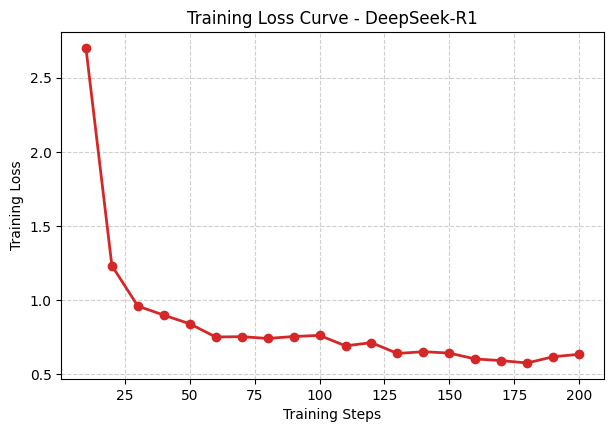

✅ Đã vẽ và lưu thành công biểu đồ tại: figures/loss_curve_deepseek.png


In [8]:
import matplotlib.pyplot as plt
import os

# 1. Tạo thư mục figures để chứa ảnh
os.makedirs('figures', exist_ok=True)

# 2. Trích xuất dữ liệu Loss từ lịch sử huấn luyện của biến 'trainer'
log_history = trainer.state.log_history

steps = []
losses = []
for log in log_history:
    if 'loss' in log and 'step' in log:
        steps.append(log['step'])
        losses.append(log['loss'])

# 3. Cấu hình màu sắc và tên file tùy theo mô hình
model_name_title = "DeepSeek-R1"       
save_filename = "loss_curve_deepseek.png" # Đổi thành "loss_curve_qwen.png" hoặc "loss_curve_deepseek.png"
line_color = "#d62728"             # Xanh dương cho Llama (#2ca02c cho Qwen, #d62728 cho DeepSeek)
# -----------------------------------------------------------

# 4. Vẽ biểu đồ
plt.figure(figsize=(7, 4.5))
plt.plot(steps, losses, marker='o', linestyle='-', color=line_color, linewidth=2)

plt.title(f'Training Loss Curve - {model_name_title}')
plt.xlabel('Training Steps')
plt.ylabel('Training Loss')
plt.grid(True, linestyle='--', alpha=0.6)

# 5. Lưu ảnh chất lượng cao 300 DPI theo chuẩn bài báo
save_path = f'figures/{save_filename}'
plt.savefig(save_path, bbox_inches='tight', dpi=300)
plt.show()

print(f"✅ Đã vẽ và lưu thành công biểu đồ tại: {save_path}")

In [9]:
import matplotlib.pyplot as plt

def save_text_as_image(text, filename, title):
    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.axis('off') # Tắt trục tọa độ
    
    # Vẽ khung chữ nhật chứa text
    ax.text(0.02, 0.95, text, fontsize=10, family='monospace',
            verticalalignment='top', horizontalalignment='left',
            bbox=dict(boxstyle="round,pad=0.8", facecolor="#f8f9fa", edgecolor="#ced4da", linewidth=1.5))
    
    plt.title(title, pad=10, fontweight='bold', fontsize=12)
    plt.savefig(f'figures/{filename}', bbox_inches='tight', dpi=150)
    plt.close()

# 1. Đoạn text mẫu JSONL
jsonl_text = """{
  "text": "Below is an instruction that describes a task... \\n\\n
  ### Input:\\n
  the use of validation rule base enables verifying...\\n\\n
  ### Response:\\n
  {\\"Sentiment\\": \\"neutral\\"}",
  "label": "neutral"
}"""

# 2. Đoạn text suy luận của DeepSeek
reasoning_text = """<think>
The sentence mentions "operating profit fell to EUR 35.4 mn from EUR 68.8 mn".
The word "fell" and the decrease in profit indicate a declining financial performance.
Therefore, this is clearly a negative statement.
</think>
{"Sentiment": "negative"}"""

# Gọi hàm lưu thành ảnh
save_text_as_image(jsonl_text, "jsonl_sample.png", "Mẫu định dạng dữ liệu JSONL")
save_text_as_image(reasoning_text, "deepseek_reasoning_example.png", "Ví dụ suy luận (Reasoning Trace) của DeepSeek-R1")

print("✅ Đã lưu thành công: figures/jsonl_sample.png")
print("✅ Đã lưu thành công: figures/deepseek_reasoning_example.png")

✅ Đã lưu thành công: figures/jsonl_sample.png
✅ Đã lưu thành công: figures/deepseek_reasoning_example.png
